# OOP example using Banking system

Implement the following objects. You have the freedom to implement your desired behaviors of the methods as long as the behaviors match the name of the method.

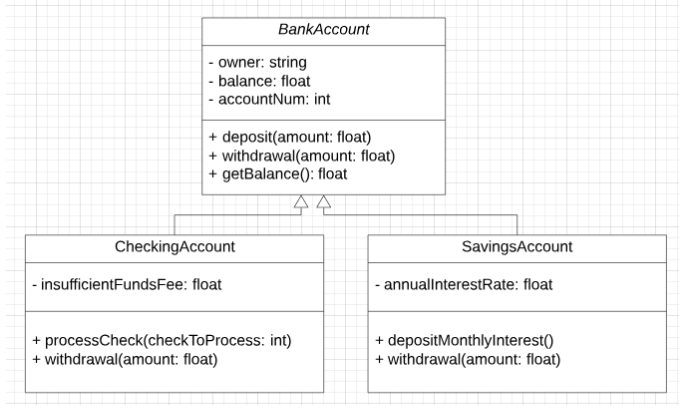

_NOTE:_ This notebook is more advance than the scope of this class and is for your reference if you want to learn more on OOP.

Why use OOP?
Here we will use class to group attributes and function/methods of different bank account.


**Encapsulation**: Private and protected attributes so that we can protect account details and ensures controlled access

**Inheritance**: By reusing  BankAccount code, we can create CheckingAccount and SavingsAccount via inheriting from BankAccount

**Polymorphism**: Both subclasses use the withdrawal() method but it behaves differently depending on the account

**Scalability**: OOP allows us to easily add new account types (e.g., BusinessAccount) or features

In [ ]:
class BankAccount:
    def __init__(self, owner, balance, accountNum):
        self._owner = owner  # private
        self._balance = balance  # private
        self._accountNum = accountNum  # private

    def deposit(self, amount):
        if amount > 0:
            self._balance += amount
            print(f"{amount} deposited. New balance: {self._balance}")
        else:
            print("Deposit amount must be positive.")

    def withdrawal(self, amount):
        if amount > 0 and amount <= self._balance:
            self._balance -= amount
            print(f"{amount} withdrawn. New balance: {self._balance}")
        else:
            print("Insufficient balance or invalid amount.")

    def getBalance(self):
        return self._balance


class CheckingAccount(BankAccount):
    def __init__(self, owner, balance, accountNum, insufficientFundsFee):
        super().__init__(owner, balance, accountNum)
        self._insufficientFundsFee = insufficientFundsFee

    def processCheck(self, checkToProcess):
        print(f"Processing check for: {checkToProcess}")
        self.withdrawal(checkToProcess)

    def withdrawal(self, amount):
        if amount > self._balance:
            print(f"Overdraft! Applying fee of {self._insufficientFundsFee}")
            self._balance -= self._insufficientFundsFee
        else:
            self._balance -= amount
            print(f"{amount} withdrawn. New balance: {self._balance}")


class SavingsAccount(BankAccount):
    def __init__(self, owner, balance, accountNum, annualInterestRate):
        super().__init__(owner, balance, accountNum)
        self._annualInterestRate = annualInterestRate

    def depositMonthlyInterest(self):
        monthly_rate = self._annualInterestRate / 12
        interest = self._balance * (monthly_rate / 100)
        self._balance += interest
        print(f"Monthly interest of {interest:.2f} added. New balance: {self._balance}")

    def withdrawal(self, amount):
        if amount > self._balance:
            print("Cannot withdraw: Insufficient funds.")
        else:
            self._balance -= amount
            print(f"{amount} withdrawn. New balance: {self._balance}")


In [ ]:
## Checking account example
acc1 = CheckingAccount("Alice", 500, 1001, 35)
acc1.processCheck(600)  # Overdraft

## Public account example
acc2 = SavingsAccount("Bob", 1000, 1002, 4.5)
acc2.depositMonthlyInterest()
acc2.withdrawal(1200)  # Should warn of insufficient funds


Processing check for: 600
Overdraft! Applying fee of 35
Monthly interest of 3.75 added. New balance: 1003.75
Cannot withdraw: Insufficient funds.


# Practice building a Library Management System

In this coding challenge, you are tasked with creating a simplified Library Management System using Python's Object-Oriented Programming (OOP) concepts. This system will manage books and their availability, handle user memberships, and process checkouts.

Requirements
You are required to demonstrate the use of inheritance, association, polymorphism, along with the use of private and protected attributes. Below are the details of the classes you need to implement:

### Book Class:*

Attributes:

title (protected): The title of the book. *Protected* means that members of the subclasses are allow to access.

author (private): The author of the book. *Private* means only members of the same class are allow to access

is_available(public): A boolean that is True if the book is available for checkout, False otherwise. *Public* means that everyone of the subclasses are allow to access.

Methods:

Constructor to initialize the book's title, author, and availability.

check_out(): If the book is being checked out and is available(is true), set is_available to False.

return_book(): The book is being returned so set is_available to True.

Getters and setters for the title and author(The attributes with different visibility need special methods to access and change variables in other classes), with the setter for author being protected.


## Book Class
-----------
Attributes
* title (protected): The title of the book.
* author (private): The author of the book.
* is_available(public): A boolean that is True if the book is available for checkout, False otherwise.

Methods:
* Constructor to initialize the book's title, author, and availability.
* check_out(): If the book is being checked out and is available(is true), set is_available to False.
* return_book(): The book is being returned so set is_available to True.

Getters and setters for the title and author(The attributes with different visibility need special methods to access and change variables in other classes), with the setter for author being protected.

In [ ]:
class Book:
    def __init__(self, title, author):


    def check_out(self):


    def return_book(self):

    def get_title(self):


    def set_title(self, title):


    def get_author(self):


    def _set_author(self, author):



### *User Class:*

Attributes:
* name (protected): Name of the user.
* membership_id (private): A unique ID for the user membership.
* books_checked_out: A list to store books currently checked out by the user.

Methods:
* Constructor to initialize the user's name and membership ID.
* check_out_book(book): Add **a** book to books_checked_out if it's available(hint: think abou whcih attribute would indicate this).
* return_book(book): Remove a book from books_checked_out list and update the book's availability.
* validate_membership_id: Protected method to validate the membership ID format.


In [ ]:
class User:
    def __init__(self, name, membership_id):
        self._name = name
        self.__membership_id = membership_id
        self.books_checked_out = []

    def check_out_book(self, book):

    def return_book(self, book):


    def _validate_membership_id(self):
        return isinstance(self.__membership_id, str) and len(self.__membership_id) > 0


### *Librarian Class (Inherits from User):*

Attributes:
* employee_number(public): A unique number identifying the librarian.

Methods:
* Constructor to initialize the librarian's name, membership ID, and employee number.

* Override the check_out_book(book) method to allow multiple books to be checked out simultaneously.

* organize_books(): A method that prints out that the librarian is organizing books.

In [ ]:
class Librarian(User):
    def __init__(self, name, membership_id, employee_number):
        super().__init__(name, membership_id)
        self.employee_number = employee_number

    def check_out_book(self, *books):

    def organize_books(self):
        print("Librarian is organizing books...")



### *Library Class:*

Attributes:

* books: A dictionary to store book instances with their titles as keys.

* members: A list of User objects (This shows association, as the library has users).

Methods:

* Constructor to initialize the library with a list of books.
* add_book(book): Add a new book to the library(add a book object to the books attribute).
* remove_book(title): Remove a book from the library by title. Check if title is in books, if dound then remove else prompt the user.
* add_member(user): Add a new member to the library.

In [ ]:
class Library:
    def __init__(self, books=[]):
        self.books = {book.get_title(): book for book in books}
        self.members = []

    def add_book(self, book):

    def remove_book(self, title):

    def add_member(self, user):


## Use case of Library Management System

In [ ]:
if __name__ == "__main__":
    book1 = Book("1984", "George Orwell")
    book2 = Book("Brave New World", "Aldous Huxley")
    user1 = User("Alice", "M001")
    librarian = Librarian("Bob", "L001", "E123")

    library = Library([book1])
    library.add_book(book2)
    library.add_member(user1)
    library.add_member(librarian)

    user1.check_out_book(book1)
    librarian.check_out_book(book2)
    librarian.organize_books()


Librarian is organizing books...
